# **COMPARAISON : Isolation Forest vs Deep Autoencoder**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)
from tensorflow.keras.models import load_model

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Imports OK")

Imports OK


## 1. Chargement des deux modèles + reconstruction du même test set

On reconstruit le split temporel exactement comme dans les deux notebooks
sources, à partir de `X_raw.csv`, pour garantir que `X_test` / `y_test`
sont identiques pour les deux modèles.

In [2]:
# ── Charger depuis features_ml.csv (contient toutes les colonnes des 2 modèles) ──
features_df = pd.read_csv("../data/features_ml.csv")
features_df_sorted = features_df.sort_values("timestamp").reset_index(drop=True)

y_full = features_df_sorted["is_anomaly"]

n = len(features_df_sorted)
test_start = int(n * 0.80)

X_test_raw = features_df_sorted.iloc[test_start:].reset_index(drop=True)
y_test = y_full.iloc[test_start:].reset_index(drop=True)

print(f"Test set reconstruit depuis features_ml.csv")
print(f"X_test_raw : {X_test_raw.shape}")
print(f"y_test     : {y_test.shape}  —  anomalies : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
# Charger les artefacts de l'Autoencoder
ae_model = load_model("../ml/autoencoder_model.keras")
with open("../ml/autoencoder_metadata.json", "r") as f:
    ae_meta = json.load(f)
with open("../data/auto_scaler.pkl", "rb") as f:
    ae_scaler = pickle.load(f)
with open("../data/auto_clip_bounds.pkl", "rb") as f:
    ae_clip_bounds = pickle.load(f)

print(f"Autoencoder chargé")
print(f"Threshold : {ae_meta['threshold']:.6f}")
print(f"Features  : {len(ae_meta['features'])}")

# Charger les artefacts de l'Isolation Forest 
with open("../data/isolation_forest_unsupervised.pkl", "rb") as f:
    if_artifact = pickle.load(f)

if_model= if_artifact["model"]
if_scaler = if_artifact["scaler"]
if_clip_bounds = if_artifact["clip_bounds"]
if_features = if_artifact["feature_names"]
if_threshold= if_artifact["threshold"]
print(f"Isolation Forest chargé")
print(f"Threshold : {if_threshold:.6f}")
print(f"Features  : {len(if_features)}")
print(f"Contamination : {if_artifact['contamination']}")
print(f"n_estimators  : {if_artifact['n_estimators']}")

Test set reconstruit depuis features_ml.csv
X_test_raw : (889, 53)
y_test     : (889,)  —  anomalies : 34 (3.8%)
Autoencoder chargé
Threshold : 0.492928
Features  : 46
Isolation Forest chargé
Threshold : 0.550116
Features  : 46
Contamination : 0.02
n_estimators  : 200


## 2. Préparer les données de test pour chaque modèle

Chaque modèle a sa propre liste de features et son propre scaler et on
applique exactement le même pipeline que celui utilisé à l'entraînement
de chacun (clip → scale).

In [3]:
# Préparation pour l'Autoencoder 
X_test_ae = X_test_raw[ae_meta["features"]].copy()
for col, (low, high) in ae_clip_bounds.items():
    X_test_ae[col] = X_test_ae[col].clip(lower=low, upper=high)
X_test_ae_scaled = ae_scaler.transform(X_test_ae).astype("float32")

# Préparation pour l'Isolation Forest 
X_test_if = X_test_raw[if_features].copy()
for col, (low, high) in if_clip_bounds.items():
    X_test_if[col] = X_test_if[col].clip(lower=low, upper=high)
X_test_if_scaled = if_scaler.transform(X_test_if)

print("Données préparées pour les deux modèles")
print(f"X_test_ae_scaled : {X_test_ae_scaled.shape}")
print(f"X_test_if_scaled : {X_test_if_scaled.shape}")

Données préparées pour les deux modèles
X_test_ae_scaled : (889, 46)
X_test_if_scaled : (889, 46)


## 3. Calcul des scores d'anomalie

- **Autoencoder** : score = erreur de reconstruction (MSE)
- **Isolation Forest** : score = `-score_samples()` (plus c'est élevé, plus c'est anormal)

Les deux scores sont sur des échelles différentes, donc on les compare
via des métriques indépendantes de l'échelle (AUC, Average Precision)
et via les prédictions binaires à leur seuil optimal respectif.

In [4]:
# Scores Autoencoder
ae_recon  = ae_model.predict(X_test_ae_scaled, verbose=0)
ae_scores = np.mean(np.power(X_test_ae_scaled - ae_recon, 2), axis=1)
ae_pred   = (ae_scores > ae_meta["threshold"]).astype(int)
# Scores Isolation Forest
if_scores = -if_model.score_samples(X_test_if_scaled)
if_pred  = (if_scores >= if_threshold).astype(int)
print("Scores calculés pour les deux modèles")
print(f"Autoencoder scores : min={ae_scores.min():.4f}, max={ae_scores.max():.4f}")
print(f"Isolation Forest scores : min={if_scores.min():.4f}, max={if_scores.max():.4f}")

Scores calculés pour les deux modèles
Autoencoder scores : min=0.0049, max=2705.5979
Isolation Forest scores : min=0.3432, max=0.6721


## 4. Tableau comparatif des métriques

On calcule toutes les métriques standards pour les deux modèles sur le
même `y_test`, afin d'obtenir une comparaison directe et valide.

In [5]:
def compute_metrics(y_true, y_pred, scores, name):
    return {
        "Modèle"          : name,
        "Precision"       : precision_score(y_true, y_pred, zero_division=0),
        "Recall"          : recall_score(y_true, y_pred, zero_division=0),
        "F1 Score"        : f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC"         : roc_auc_score(y_true, scores),
        "Avg Precision"   : average_precision_score(y_true, scores),
    }

metrics_ae = compute_metrics(y_test, ae_pred, ae_scores, "Deep Autoencoder")
metrics_if = compute_metrics(y_test, if_pred, if_scores, "Isolation Forest")

comparison_df = pd.DataFrame([metrics_ae, metrics_if]).set_index("Modèle")
comparison_df = comparison_df.round(4)

print("=" * 70)
print("   TABLEAU COMPARATIF: Isolation Forest vs Deep Autoencoder")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)

# Détail des confusions
cm_ae = confusion_matrix(y_test, ae_pred)
cm_if = confusion_matrix(y_test, if_pred)
tn_ae, fp_ae, fn_ae, tp_ae = cm_ae.ravel()
tn_if, fp_if, fn_if, tp_if = cm_if.ravel()

print(f"\nDeep Autoencoder   — TP={tp_ae}, FP={fp_ae}, FN={fn_ae}, TN={tn_ae}")
print(f"Isolation Forest   — TP={tp_if}, FP={fp_if}, FN={fn_if}, TN={tn_if}")
print(f"\nAnomalies manquées (FN) — Autoencoder : {fn_ae}/34   |   Isolation Forest : {fn_if}/34")
print(f"Fausses alertes (FP)    — Autoencoder : {fp_ae}        |   Isolation Forest : {fp_if}")

   TABLEAU COMPARATIF: Isolation Forest vs Deep Autoencoder
                  Precision  Recall  F1 Score  ROC AUC  Avg Precision
Modèle                                                               
Deep Autoencoder     0.6818  0.8824    0.7692   0.9930         0.9098
Isolation Forest     0.6136  0.7941    0.6923   0.9871         0.7237

Deep Autoencoder   — TP=30, FP=14, FN=4, TN=841
Isolation Forest   — TP=27, FP=17, FN=7, TN=838

Anomalies manquées (FN) — Autoencoder : 4/34   |   Isolation Forest : 7/34
Fausses alertes (FP)    — Autoencoder : 14        |   Isolation Forest : 17


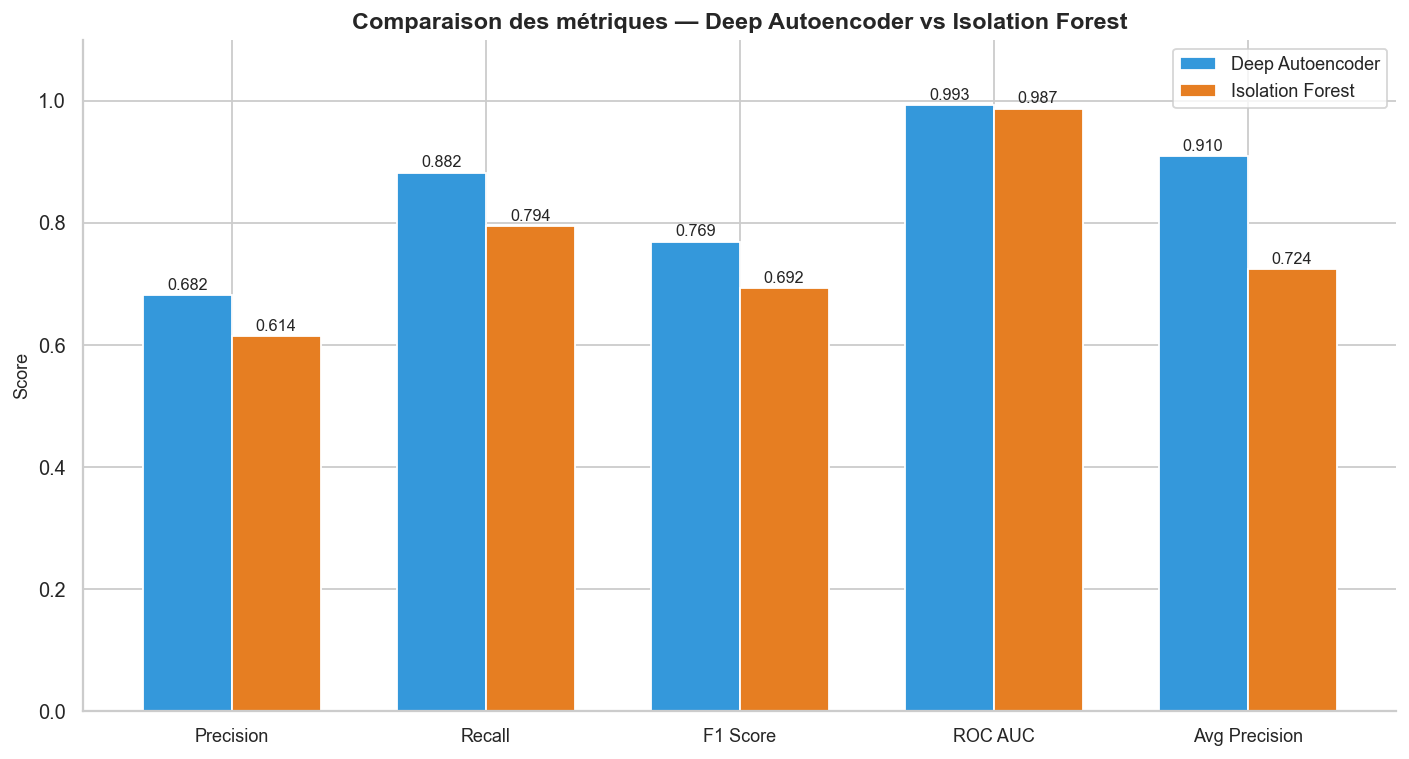

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

metrics_to_plot = ["Precision", "Recall", "F1 Score", "ROC AUC", "Avg Precision"]
x = np.arange(len(metrics_to_plot))
width = 0.35

ae_values = [metrics_ae[m] for m in metrics_to_plot]
if_values = [metrics_if[m] for m in metrics_to_plot]

bars1 = ax.bar(x - width/2, ae_values, width, label="Deep Autoencoder",
               color="#3498db", edgecolor="white")
bars2 = ax.bar(x + width/2, if_values, width, label="Isolation Forest",
               color="#e67e22", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Comparaison des métriques — Deep Autoencoder vs Isolation Forest",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("report/comparison_metrics.png", bbox_inches="tight")
plt.show()

## 6. Comparaison des matrices de confusion côte à côte

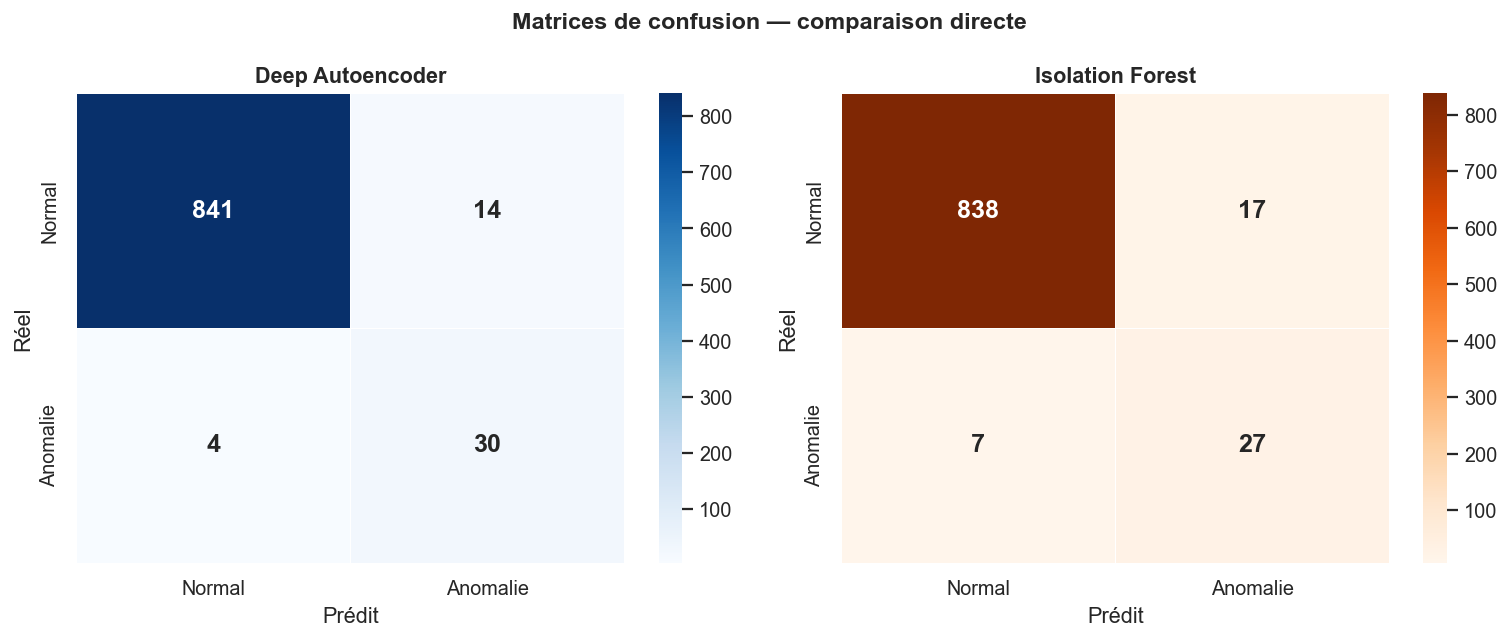

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_ae, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomalie"], yticklabels=["Normal", "Anomalie"],
            ax=axes[0], annot_kws={"size": 14, "weight": "bold"}, linewidths=0.5)
axes[0].set_title("Deep Autoencoder", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")

sns.heatmap(cm_if, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "Anomalie"], yticklabels=["Normal", "Anomalie"],
            ax=axes[1], annot_kws={"size": 14, "weight": "bold"}, linewidths=0.5)
axes[1].set_title("Isolation Forest", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Réel")

plt.suptitle("Matrices de confusion — comparaison directe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("report/comparison_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 8. Comparaison des courbes Precision-Recall

Vu le fort déséquilibre des classes (3.8% d'anomalies), la courbe
Precision-Recall est souvent plus informative que la ROC pour juger
de la qualité réelle de détection.

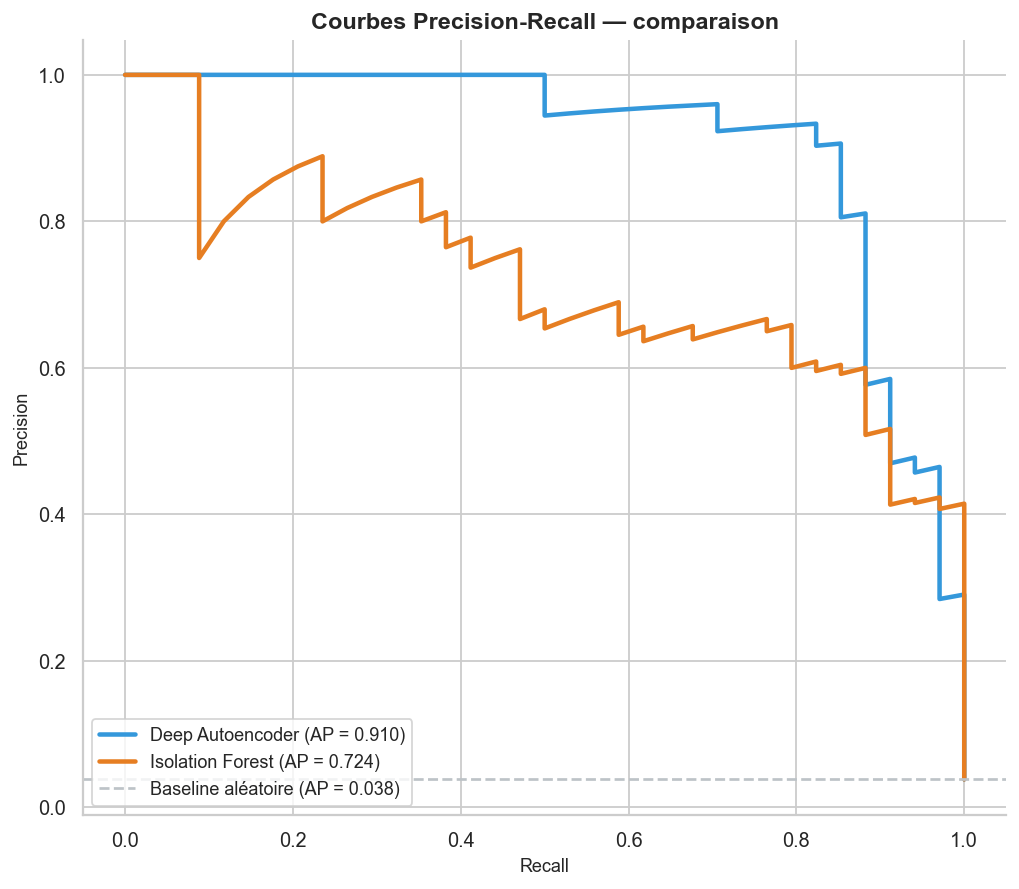

In [8]:
prec_ae, rec_ae, _ = precision_recall_curve(y_test, ae_scores)
prec_if, rec_if, _ = precision_recall_curve(y_test, if_scores)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(rec_ae, prec_ae, color="#3498db", linewidth=2.5,
        label=f"Deep Autoencoder (AP = {metrics_ae['Avg Precision']:.3f})")
ax.plot(rec_if, prec_if, color="#e67e22", linewidth=2.5,
        label=f"Isolation Forest (AP = {metrics_if['Avg Precision']:.3f})")
ax.axhline(y_test.mean(), color="#bdc3c7", linestyle="--", linewidth=1.5,
           label=f"Baseline aléatoire (AP = {y_test.mean():.3f})")

ax.set_title("Courbes Precision-Recall — comparaison",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.legend(fontsize=10, loc="lower left")

plt.tight_layout()
plt.savefig("report/comparison_pr_curves.png", bbox_inches="tight")
plt.show()

## 9. Anomalies détectées par les deux modèles — overlap

Est-ce que les deux modèles détectent les mêmes anomalies, ou sont-ils
complémentaires (chacun détecte des cas différents) ?

=== Overlap de détection sur les 34 vraies anomalies ===

Détectées par les DEUX modèles      : 23
Détectées par l'Autoencoder SEUL    : 7
Détectées par Isolation Forest SEUL : 4
Manquées par les DEUX modèles       : 0


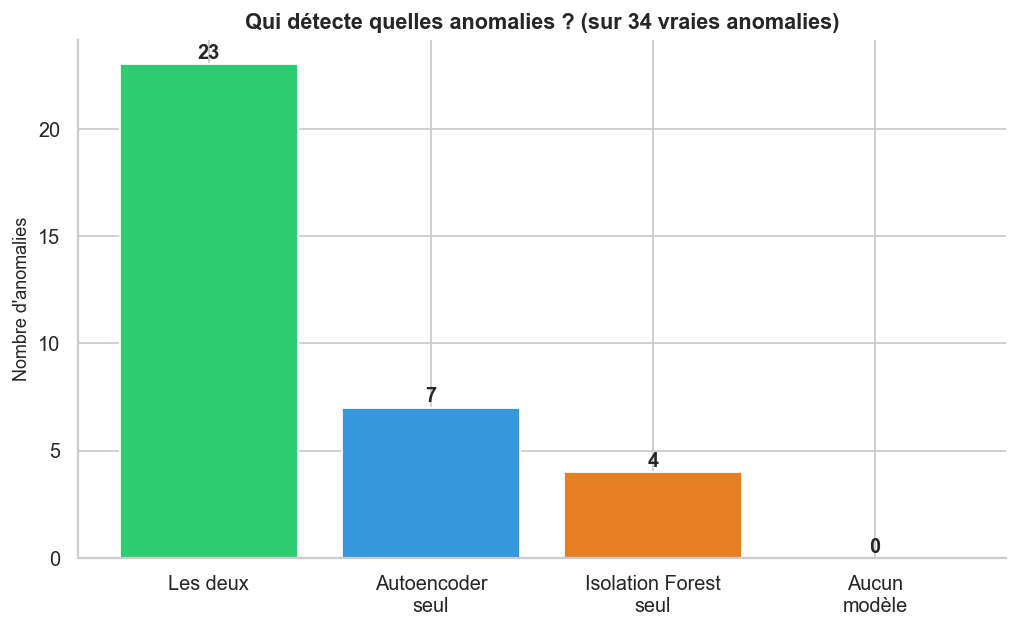


💡 Les modèles sont partiellement complémentaires —
   un système combinant les deux (ensemble) pourrait améliorer le recall global.


In [9]:
anomaly_indices = set(np.where(y_test.values == 1)[0])
ae_detected      = set(np.where((ae_pred == 1) & (y_test.values == 1))[0])
if_detected      = set(np.where((if_pred == 1) & (y_test.values == 1))[0])

both       = ae_detected & if_detected
only_ae    = ae_detected - if_detected
only_if    = if_detected - ae_detected
missed_all = anomaly_indices - ae_detected - if_detected

print("=== Overlap de détection sur les 34 vraies anomalies ===\n")
print(f"Détectées par les DEUX modèles      : {len(both)}")
print(f"Détectées par l'Autoencoder SEUL    : {len(only_ae)}")
print(f"Détectées par Isolation Forest SEUL : {len(only_if)}")
print(f"Manquées par les DEUX modèles       : {len(missed_all)}")

# Diagramme de Venn simplifié en barres
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Les deux", "Autoencoder\nseul", "Isolation Forest\nseul", "Aucun\nmodèle"]
counts     = [len(both), len(only_ae), len(only_if), len(missed_all)]
colors     = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

bars = ax.bar(categories, counts, color=colors, edgecolor="white")
for bar, count in zip(bars, counts):
    ax.annotate(str(count), xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center",
                fontsize=11, fontweight="bold")

ax.set_title("Qui détecte quelles anomalies ? (sur 34 vraies anomalies)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Nombre d'anomalies", fontsize=10)

plt.tight_layout()
plt.savefig("report/comparison_detection_overlap.png", bbox_inches="tight")
plt.show()

if len(only_ae) > 0 or len(only_if) > 0:
    print("\n💡 Les modèles sont partiellement complémentaires —")
    print("   un système combinant les deux (ensemble) pourrait améliorer le recall global.")

## 10. Synthèse finale et recommandation

On résume les forces et faiblesses de chaque modèle pour conclure
sur lequel déployer en production (ou si une approche hybride est
préférable).

In [10]:
print("=" * 65)
print("   SYNTHÈSE FINALE — DEEP AUTOENCODER vs ISOLATION FOREST")
print("=" * 65)
print(comparison_df.to_string())
print("=" * 65)

winner_f1   = comparison_df["F1 Score"].idxmax()
winner_auc  = comparison_df["ROC AUC"].idxmax()
winner_rec  = comparison_df["Recall"].idxmax()
winner_prec = comparison_df["Precision"].idxmax()

print(f"\nMeilleur F1 Score   : {winner_f1}  ({comparison_df.loc[winner_f1, 'F1 Score']:.3f})")
print(f"Meilleur ROC AUC    : {winner_auc}  ({comparison_df.loc[winner_auc, 'ROC AUC']:.3f})")
print(f"Meilleur Recall     : {winner_rec}  ({comparison_df.loc[winner_rec, 'Recall']:.3f})")
print(f"Meilleure Precision : {winner_prec}  ({comparison_df.loc[winner_prec, 'Precision']:.3f})")

print(f"\n=== Recommandation ===")
if comparison_df.loc["Deep Autoencoder", "Recall"] > comparison_df.loc["Isolation Forest", "Recall"]:
    print("L'Autoencoder rate moins d'anomalies (Recall supérieur)")
    print("→ Recommandé si l'objectif est de minimiser les anomalies manquées")
else:
    print("Isolation Forest rate moins d'anomalies (Recall supérieur)")
    print("→ Recommandé si l'objectif est de minimiser les anomalies manquées")

if comparison_df.loc["Deep Autoencoder", "Precision"] > comparison_df.loc["Isolation Forest", "Precision"]:
    print("L'Autoencoder génère moins de fausses alertes (Precision supérieure)")
else:
    print("Isolation Forest génère moins de fausses alertes (Precision supérieure)")



   SYNTHÈSE FINALE — DEEP AUTOENCODER vs ISOLATION FOREST
                  Precision  Recall  F1 Score  ROC AUC  Avg Precision
Modèle                                                               
Deep Autoencoder     0.6818  0.8824    0.7692   0.9930         0.9098
Isolation Forest     0.6136  0.7941    0.6923   0.9871         0.7237

Meilleur F1 Score   : Deep Autoencoder  (0.769)
Meilleur ROC AUC    : Deep Autoencoder  (0.993)
Meilleur Recall     : Deep Autoencoder  (0.882)
Meilleure Precision : Deep Autoencoder  (0.682)

=== Recommandation ===
L'Autoencoder rate moins d'anomalies (Recall supérieur)
→ Recommandé si l'objectif est de minimiser les anomalies manquées
L'Autoencoder génère moins de fausses alertes (Precision supérieure)


In [11]:
# Quelle est l'index de la première anomalie dans X_test ?
first_anomaly_idx = np.where(y_test == 1)[0][0]

# Est-ce que l'IF la détecte ?
X_sample = X_test_if[first_anomaly_idx:first_anomaly_idx+1]
if_prediction = if_model.predict(X_sample)
print(f"IF prediction : {if_prediction}")  # -1 = anomalie, 1 = normal


IF prediction : [-1]


NameError: name 'imputer' is not defined